In [102]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score , mean_squared_error
from sklearn.preprocessing import StandardScaler

In [103]:
dataset=pd.read_csv("height-weight.csv")

In [104]:
dataset.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


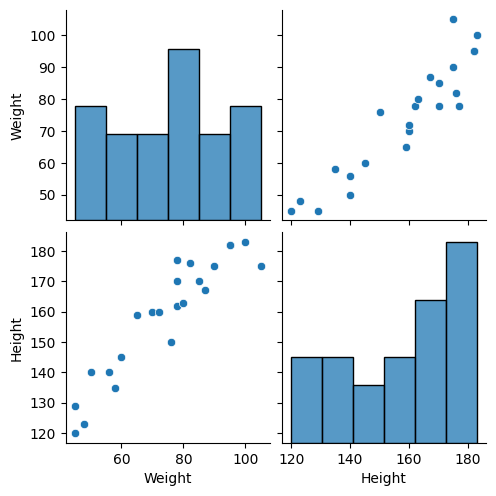

In [105]:
sns.pairplot(dataset)

In [106]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 496.0 bytes


In [107]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [108]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [109]:
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [110]:
X_train , X_test , y_train , y_test = train_test_split(X  , y , test_size=0.25 , random_state=42)

In [111]:
X_train.head()

,Weight
1,58
13,100
5,78
2,48
11,95


In [112]:
scaler=StandardScaler()

In [113]:
X_train=scaler.fit_transform(X_train)

In [114]:
X_test=scaler.transform(X_test)

In [115]:
model=LinearRegression()

In [116]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
y_pred=model.predict(X_test)

In [118]:
mae=mean_absolute_error(y_test , y_pred)
mse=mean_squared_error(y_test , y_pred)
score=r2_score(y_test , y_pred)

In [119]:
mae , mse , score

(9.66512588679501, 114.84069295228699, 0.7360826717981276)

In [120]:
import matplotlib.pyplot as plt

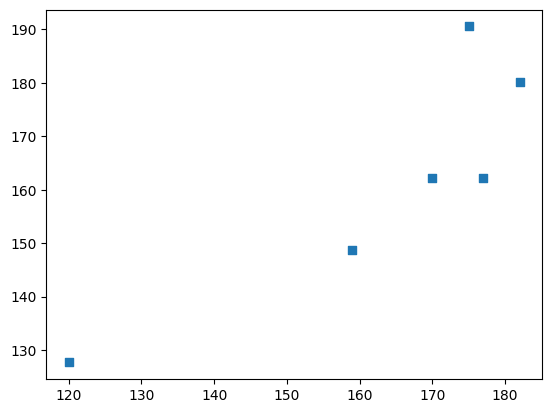

In [121]:
plt.scatter(y_test , y_pred , marker="s")

In [122]:
dataset.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


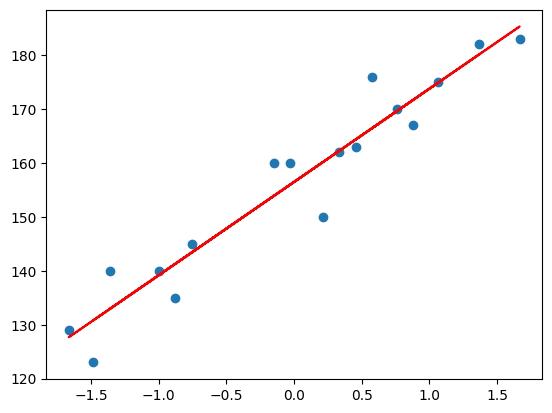

In [125]:
plt.scatter(X_train , y_train)
plt.plot(X_train , model.predict(X_train),color="red")

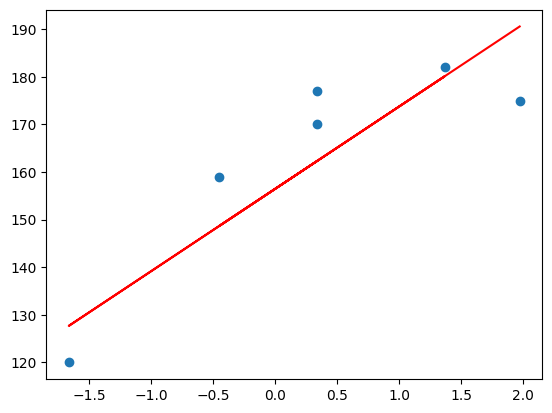

In [126]:
plt.scatter(X_test , y_test)
plt.plot(X_test , model.predict(X_test),color="red")

In [127]:
import joblib

In [132]:
joblib.dump(model,'simple_linear_regression.pkl')

['simple_linear_regression.pkl']